In [1]:
import csv
import copy
import random
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import pandas as pd

from time import sleep
from collections import deque, defaultdict
from itertools import count
from typing import Any, Dict, Counter, List
from dataclasses import dataclass

from torch.distributions import Categorical

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import torch_optimizer as optim_extra

from importnb import Notebook
with Notebook():
    from LabLatencyModel import LatencyModel, MultiDULatencyModel
    from LabCacheEngine import CacheEngineEnv
    from LabUserRequest import UserRequestEvents
    from LabEnvWrapperDudu import EnvWrapper

import os
import sys

sources_path = os.path.abspath(os.path.join(os.getcwd(), '..'))
if sources_path not in sys.path:
    sys.path.append(sources_path)

import Common.config as config
import Common.datatypes as datatypes
import Common.utils as utils

import importlib

importlib.reload(config)
importlib.reload(datatypes)
importlib.reload(utils)

<module 'Common.utils' from 'c:\\Users\\es25591\\Workspace\\CacheVideoPredict360\\Sources\\Common\\utils.py'>

In [2]:
UserTransition = datatypes.UserTransition
CachePolicy = datatypes.CachePolicy
CacheKey = datatypes.CacheKey

cfg = config.Config()
cfg.state_dim = 10 * cfg.cache_size + 10 # [x_s, x_l, y_s, y_l, z_s, z_l]
cfg.action_dim = 5 # [Base_N, Enh_N, Enh_N, Enh_N, Enh_N]
cfg.filename = f"drl_dudu_eps{cfg.epsilon_decay}_lrdecay{cfg.learning_rate_decay}_c{cfg.cache_size}_ar{cfg.arrival_rate}_z{cfg.zipf_alpha}.csv"

In [3]:
class DrlPolicy(CachePolicy):
    def __init__(self, cfg: Any = None):
        self.cfg = cfg
        self.cur_size = 0

        self.video_idx = [-1] * self.cfg.cache_size
        self.tile_idx = [[-1] * self.cfg.viewport for _ in range(self.cfg.cache_size)]

    def get(self, key: CacheKey) -> Any:
        return self.cache.get(key, None)
    
    def put(self, vid_slot: int, value: Any, size: int) -> list:
        """
        vid_slot   -> slot index
        value -> (video_id, tiles)
        size  -> fixed as 1 slot
        """
        evicted = []
        new_video, _ = value
        
        if new_video in self.video_idx:
            old_video_slot = self.video_idx.index(new_video)
            if old_video_slot != vid_slot:
                # Swap video positions
                self.video_idx[vid_slot], self.video_idx[old_video_slot] = (
                    self.video_idx[old_video_slot],
                    self.video_idx[vid_slot],
                )

                # Swap tile mapping accordingly
                self.tile_idx[vid_slot], self.tile_idx[old_video_slot] = (
                    self.tile_idx[old_video_slot],
                    self.tile_idx[vid_slot],
                )

            self.cur_size = sum(1 for v in self.video_idx if v != -1)
            return evicted

        self.video_idx[vid_slot] = new_video
        self.tile_idx[vid_slot] = [-1] * self.cfg.viewport

        self.cur_size = sum(1 for v in self.video_idx if v != -1)
        return evicted

    def contains(self, vid: int) -> bool:
        return vid in self.video_idx

    def remove(self, vid: int) -> bool:
        if vid in self.video_idx:
            idx = self.video_idx.index(vid)
            self.video_idx[idx] = -1
            self.tile_idx[idx] = [-1] * self.cfg.viewport
            self.cur_size = sum(1 for v in self.video_idx if v != -1)
            return True
        return False

    def clear(self) -> None:
        self.video_idx = [-1] * self.cfg.cache_size
        self.tile_idx = [[-1] * self.cfg.viewport for _ in range(self.cfg.cache_size)]
        self.cur_size = 0

    def keys(self):
        return self.video_idx
    
    def get_capacity(self) -> int:
        return self.cur_size
    
    def update_size(self):
        self.cur_size = sum(1 for v in self.video_idx if v != -1)

    def stats(self) -> Dict[str, Any]:
        return {
            'current_size': self.cur_size,
            'capacity': self.cfg.cache_size,
            'num_items': len([v for v in self.video_idx if v != -1])
        }

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class ActorCritic(nn.Module):
    def __init__(self, state_dim: int, action_dims: list, hidden_dim: int = 256):
        """
        action_dims: List of ints, e.g., [Base_N, Enh_N, Enh_N, Enh_N, Enh_N]
        """
        super(ActorCritic, self).__init__()
        
        # Shared feature extractor
        self.feature_extractor = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh()
        )
        
        # Critic Head (Value function)
        self.value_head = nn.Linear(hidden_dim, 1)
        
        # Actor Heads (One for Base, One per Tile in viewport)
        # This creates the "Meta" vs "Sub" controller structure within one net
        self.actor_heads = nn.ModuleList([
            nn.Linear(hidden_dim, dim) for dim in action_dims
        ])
        
        self.action_dims = action_dims
        self.cfg = config.Config()

    def forward(self, state):
        features = self.feature_extractor(state)
        value = self.value_head(features)

        return value

    def get_action(self, state):
        """
        Samples actions conditionally.
        If Base Head selects 0, Enhancement Heads are forced to 0.
        """
        if state.dim() == 1:
            state = state.unsqueeze(0)
        
        features = self.feature_extractor(state)
        actions = []
        log_probs = []
        
        # --- 1. Base Layer (Meta Controller) ---
        base_logits = self.actor_heads[0](features)
        base_dist = Categorical(logits=base_logits)
        
        base_action = base_dist.sample()
        base_logprob = base_dist.log_prob(base_action)

        actions.append(base_action)
        log_probs.append(base_logprob)

        mask = (base_action != self.cfg.cache_size).float()
        
        # --- 2. Enhancement Layers (Controllers) ---
        for i in range(1, len(self.actor_heads)):
            logits = self.actor_heads[i](features)
            dist = Categorical(logits=logits)

            act = dist.sample()
            lp = dist.log_prob(act)

            actions.append(act * mask.long())
            log_probs.append(lp * mask)
            
        actions = torch.stack(actions, dim=1)
        total_logprob = torch.stack(log_probs, dim=0).sum(dim=0)

        value = self.value_head(features)

        return actions.squeeze(0), total_logprob.squeeze(0), value.squeeze(0)

    def evaluate(self, state, actions):
        """
        Evaluates batch of actions.
        Masks gradients for enhancement heads if Base Action was 0.
        """
        features = self.feature_extractor(state)
        
        log_probs = []
        entropies = []

        # Base head
        base_logits = self.actor_heads[0](features)
        base_dist = Categorical(logits=base_logits)

        base_act = actions[:, 0]
        base_lp = base_dist.log_prob(base_act)
        base_ent = base_dist.entropy()

        log_probs.append(base_lp)
        entropies.append(base_ent)

        mask = (base_act != self.cfg.cache_size).float()
        
        # Enhancement heads
        for i in range(1, len(self.actor_heads)):
            logits = self.actor_heads[i](features)
            dist = Categorical(logits=logits)

            act = actions[:, i]

            lp = dist.log_prob(act) * mask
            ent = dist.entropy() * mask

            log_probs.append(lp)
            entropies.append(ent)

        total_lp = torch.stack(log_probs).sum(dim=0)
        total_ent = torch.stack(entropies).sum(dim=0)

        values = self.value_head(features)

        return total_lp, values.squeeze(-1), total_ent

class PPOAgent:
    def __init__(self, cfg: Any):
        self.eps_clip = 0.2
        self.K_epochs = 10
        self.entropy_coef = cfg.entropy_coef # Controls how much we force exploration

        self.cfg = cfg
        self.epsilon_clip = 0.2
        self.gamma = cfg.gamma
        self.lamda = 0.95
        self.batch_size = cfg.batch_size

        self.policy = ActorCritic(cfg.state_dim, [cfg.cache_size + 1] + [5] * cfg.viewport).to(device)
        self.policy_old = ActorCritic(cfg.state_dim, [cfg.cache_size + 1] + [5] * cfg.viewport).to(device)
        self.policy_old.load_state_dict(self.policy.state_dict())

        self.optimizer = optim.Adam(self.policy.parameters(), lr=cfg.learning_rate)

        self.scheduler = torch.optim.lr_scheduler.ExponentialLR(
            self.optimizer, 
            gamma=cfg.learning_rate_decay
        )

        self.mse_loss = nn.MSELoss()
        self.nb_interval = cfg.nb_interval

    def select_action(self, state):
        with torch.no_grad():
            state = torch.FloatTensor(state).to(device)
            action, log_prob, _ = self.policy_old.get_action(state)
            
        return action.detach().numpy(), log_prob.detach().item()

    def update(self, memory):
        # Convert memory to tensors
        rewards = []
        discounted_reward = 0
        
        for reward, is_terminal in zip(reversed(memory.rewards), reversed(memory.is_terminals)):
            if is_terminal:
                discounted_reward = 0
            discounted_reward = reward + (self.gamma * discounted_reward)
            rewards.insert(0, discounted_reward)
            
        rewards = torch.tensor(rewards, dtype=torch.float32).to(device)
        rewards = (rewards - rewards.mean()) / (rewards.std() + 1e-7)

        old_states = torch.stack(memory.states).to(device).detach()
        old_actions = torch.stack(memory.actions).to(device).detach()
        old_logprobs = torch.stack(memory.logprobs).to(device).detach()
        
        # Optimize policy for K epochs
        for _ in range(self.K_epochs):
            # Evaluating old actions and values
            logprobs, state_values, dist_entropy = self.policy.evaluate(old_states, old_actions)
            
            state_values = torch.squeeze(state_values)
            
            # Finding the ratio (pi_theta / pi_theta__old)
            ratios = torch.exp(logprobs - old_logprobs)

            # Finding Surrogate Loss
            advantages = rewards - state_values.detach()   
            surr1 = ratios * advantages
            surr2 = torch.clamp(ratios, 1 - self.eps_clip, 1 + self.eps_clip) * advantages

            # Final loss: Policy Loss + Value Loss - Entropy Bonus
            loss = -torch.min(surr1, surr2) + 0.5 * self.mse_loss(state_values, rewards) - self.entropy_coef * dist_entropy
            
            # Take gradient step
            self.optimizer.zero_grad()
            loss.mean().backward()
            self.optimizer.step()
            
        # Copy new weights into old policy
        self.policy_old.load_state_dict(self.policy.state_dict())

    def decay_entropy_coef(self, decay_rate=0.99, min_coef=0.001):
        self.entropy_coef = max(min_coef, self.entropy_coef * decay_rate)
        return self.entropy_coef
    
    def reset_step(self):
        self.step = 0

class Memory:
    def __init__(self):
        self.actions = []
        self.states = []
        self.logprobs = []
        self.rewards = []
        self.is_terminals = []
    
    def clear_memory(self):
        del self.actions[:]
        del self.states[:]
        del self.logprobs[:]
        del self.rewards[:]
        del self.is_terminals[:]

In [5]:
class FeatureAdapter:
    def __init__(self, env: CacheEngineEnv, cfg: Any):
        self.env = env
        self.cfg = cfg

        self.video_hist_short = deque(maxlen=cfg.h_short)
        self.video_hist_long = deque(maxlen=cfg.h_long)
        self.tile_hist_short = deque(maxlen=cfg.h_short * cfg.viewport)
        self.tile_hist_long = deque(maxlen=cfg.h_long * cfg.viewport)

        self.video_freq_short = defaultdict(int)
        self.video_freq_long = defaultdict(int)
        self.tile_freq_short = defaultdict(int)
        self.tile_freq_long = defaultdict(int)
        
        self.ch_video_hist = deque(maxlen=cfg.h_long)
        self.ch_viewport_hist = deque(maxlen=cfg.h_long)

    def reset_history(self):
        queues = (
            self.video_hist_short,
            self.video_hist_long,
            self.tile_hist_short,
            self.tile_hist_long,
            self.ch_video_hist,
            self.ch_viewport_hist,
        )
        freqs = (
            self.video_freq_short,
            self.video_freq_long,
            self.tile_freq_short,
            self.tile_freq_long,
        )
        
        for q in queues:
            q.clear()
        for f in freqs:
            f.clear()

    def update_history(self, vid: int, tiles: list[int]):       
        self._update_window(self.video_hist_short, self.video_freq_short, vid)
        self._update_window(self.video_hist_long, self.video_freq_long, vid)

        tiles = tuple(tiles) if tiles is not None else None

        if tiles is None:
            return

        for tile in tiles:
            self._update_window(self.tile_hist_short, self.tile_freq_short, (vid, tile))
            self._update_window(self.tile_hist_long, self.tile_freq_long, (vid, tile))

    def update_history_single(self, item):
        if isinstance(item, int):
            self._update_window(self.video_hist_short, self.video_freq_short, item)
            self._update_window(self.video_hist_long, self.video_freq_long, item)
        elif isinstance(item, tuple) and len(item) == 2:
            self._update_window(self.tile_hist_short, self.tile_freq_short, item)
            self._update_window(self.tile_hist_long, self.tile_freq_long, item)


    def update_ch_history(self, vid: int, viewport: list[int]):
        video_cache_index = self.env.mec_cache.policy.video_idx
        tile_cache_index = self.env.mec_cache.policy.tile_idx

        hit = 1 if vid in video_cache_index else 0
        self.ch_video_hist.append(hit)
        
        if not hit:
            viewport_vector = [0,0,0,0]
        else:
            idx = video_cache_index.index(vid)
            cached_tiles = tile_cache_index[idx]
            viewport_vector = [1 if tile in cached_tiles else 0 for tile in viewport]
            
        self.ch_viewport_hist.append(viewport_vector)
        return hit + sum(viewport_vector)
    
    def compute_reward(self) -> float:
        psnr_layer_0 = 30 * sum(self.ch_video_hist)
        psnr_layer_1 = 2.5 * sum(sum(viewport) for viewport in self.ch_viewport_hist)
        
        return (psnr_layer_0 + psnr_layer_1) / len(self.ch_video_hist)
        
    def _update_window(self, hist_queue: deque, freq_dict: Dict, item):
        if len(hist_queue) == hist_queue.maxlen:
            old_item = hist_queue.popleft()
            freq_dict[old_item] -= 1
            if freq_dict[old_item] == 0:
                del freq_dict[old_item]
        hist_queue.append(item)
        freq_dict[item] += 1

In [6]:
class NetworkAdapter:
    def __init__(self, env: EnvWrapper, feature_adapter: FeatureAdapter, cfg: Any):
        self.env = env
        self.cfg = cfg
        self.features = feature_adapter

        self.C = self.cfg.cache_size  # paper's cache capacity (videos)
        self.k = self.cfg.viewport    # paper's tiles per video (enhancement)

        print(f"NetworkAdapter initialized with capacity: {self.C} videos, {self.k} tiles per video")

    def build_observation(self, vid: int, viewport: list) -> np.ndarray:
        video_cache_index = self.env.mec_cache.policy.video_idx
        tile_cache_index = self.env.mec_cache.policy.tile_idx

        x_s = np.zeros(self.C, dtype=np.float32)
        x_l = np.zeros(self.C, dtype=np.float32)

        y_s = np.zeros(self.C * self.k, dtype=np.float32)
        y_l = np.zeros(self.C * self.k, dtype=np.float32)

        for vid_i, v in enumerate(video_cache_index):
            if v == -1:
                continue
            x_s[vid_i] = self.features.video_freq_short.get(v, 0)
            x_l[vid_i] = self.features.video_freq_long.get(v, 0)

            tiles = tile_cache_index[vid_i]

            for til_i, t in enumerate(tiles):
                if t == -1:
                    continue
                y_s[vid_i * self.k + til_i] = self.features.tile_freq_short.get((v, t), 0)
                y_l[vid_i * self.k + til_i] = self.features.tile_freq_long.get((v, t), 0)

        z_s = np.zeros(len(viewport) + 1, dtype=np.float32)
        z_l = np.zeros(len(viewport) + 1, dtype=np.float32)

        z_s[0] = self.features.video_freq_short.get(vid, 0)
        z_l[0] = self.features.video_freq_long.get(vid, 0)

        for vp_i, vp in enumerate(viewport):
            z_s[vp_i + 1] = self.features.tile_freq_short.get((vid, vp), 0)
            z_l[vp_i + 1] = self.features.tile_freq_long.get((vid, vp), 0)

        features = np.concatenate([x_s, x_l, y_s, y_l, z_s, z_l], axis=0)
        return features
    
    def reset(self):
        
        obs, info = self.env.reset()
        self.features.reset_history()

        video_cache_index = [-1] * self.C
        tile_cache_index = [[-1] * self.k for _ in range(self.C)]

        cached_videos = random.sample(range(self.cfg.n_videos), k=self.C)
        video_cache_index = cached_videos

        # for each cached video, sample distinct tiles
        for i, _ in enumerate(cached_videos):
            tiles = random.sample(range(self.cfg.n_tiles), k=self.k)
            tile_cache_index[i] = tiles

        self.env.mec_cache.policy.video_idx = video_cache_index
        self.env.mec_cache.policy.tile_idx = tile_cache_index

        # --- update feature history with cached contents ---
        for i, vid in enumerate(video_cache_index):
            if vid == -1:
                continue
            tiles = tile_cache_index[i]
            self.features.update_history(vid, tiles)
        # --- end feature update ---

        return obs, info
    
    def env_is_done(self) -> bool:
        return self.env.users_env.all_users_done()

In [7]:
def save_training_results(
    path_,
    filename,
    ep, 
    total_reward, 
    cache_hits, 
    cache_misses, 
    soft_hits,
    agent
):
    with open(os.path.join(path_, filename), 'a', newline='') as f:
        fieldnames = [
            'episode', 
            'total_reward', 
            'cache_hits', 
            'cache_misses', 
            'soft_hits',
            'epsilon',
            'lr'
        ]
        writer_results = csv.DictWriter(f, fieldnames=fieldnames)

        if ep == 1:
            writer_results.writeheader()
        
        writer_results.writerow({
            'episode': ep,
            'total_reward': round(float(total_reward), 2),
            'cache_hits': cache_hits,
            'cache_misses': cache_misses,
            'soft_hits': soft_hits,
            'lr': f"{agent.scheduler.get_last_lr()[0]:.10f}" if agent else None,
            'epsilon': round(float(agent.entropy_coef), 4) if agent else None
        })

def update_metrics(info: dict, reward: float) -> tuple[float, int, int, float]:
    enh_hits = info.get("enh_layer_hits", 0)
    base_hits = info.get("base_layer_hits", 0)
    enh_misses = info.get("enh_layer_misses", 0)
    base_misses = info.get("base_layer_misses", 0)
    soft_hits = info.get("soft_hits", 0.0)

    return reward, (enh_hits + base_hits), (enh_misses + base_misses), soft_hits

def build_latency_model(cfg):
    """Build and return the MultiDULatencyModel."""
    P = cfg.n_nodes
    max_U = cfg.n_users

    return MultiDULatencyModel(
        P=P,
        max_U=max_U,
        R_M_D=80e6,
        R_C_M=125e6,
        mu=2e7,
        eta=2e5,
        B_pu_matrix=np.full((P, max_U), 20e6, dtype=float),
        gamma_pu_matrix=np.full((P, max_U), 5.0, dtype=float),
        rhoT_p=[0.2],
        lambda_p=[0.05],
        du_fixed_delay=0.001,
        mec_fixed_delay=0.005,
        cloud_fixed_delay=0.1
    )

def build_environment(cfg):
    """Construct the full multi-component environment wrapper."""
    du_caches = []

    # DRL Caching Policy
    policy = DrlPolicy(cfg=cfg)

    # MEC Cache Engine
    mec_cache = CacheEngineEnv(
        n_users=cfg.n_users,
        n_videos=cfg.n_videos,
        n_layers=cfg.n_layers,
        n_tiles=cfg.n_tiles,
        n_gops=cfg.n_gops,
        cache_capacity=cfg.cache_capacity,
        policy=policy
    )

    # User request generator
    users_env = UserRequestEvents(
        n_nodes=cfg.n_nodes,
        n_users=cfg.n_users,
        n_videos=cfg.n_videos,
        n_gops=cfg.n_gops,
        n_layers=cfg.n_layers,
        n_tiles=cfg.n_tiles,
        n=cfg.n,
        m=cfg.m,
        arrival_rate=cfg.arrival_rate,
        zipf_alpha=cfg.zipf_alpha
    )

    # Latency Model
    latency_model = build_latency_model(cfg)

    # Wrapping all into the main training environment
    return EnvWrapper(
        cfg=cfg,
        n=cfg.n,
        m=cfg.m,
        n_layers=cfg.n_layers,
        users_env=users_env,
        du_caches=du_caches,
        mec_cache=mec_cache,
        latency_model=latency_model,
        theta=cfg.theta,
        lam=cfg.lam,
        max_steps=cfg.max_steps,
        prefetch_fn=lambda cache, action: cache.drl_prefetching_dudu(action),
        reward_fn=lambda env, reqs: env.compute_reward(reqs)
    )

In [8]:
def run_episode(episode, env, agent, net_adapter, cfg):
    """Run one full training episode."""
    _, info = net_adapter.reset()
    agent.reset_step()

    cache_hits = cache_misses = 0
    soft_hits = total_reward = 0.0

    memory = Memory()
    
    for step in count(start=1, step=1):

        req_state = info["user_request"]
        video = req_state["video"]
        viewport = req_state["viewport"]

        state = net_adapter.build_observation(video, viewport)
        action, log_prob = agent.select_action(state)

        _, reward, _, info = env.step(action, req_state)
        
        net_adapter.features.update_history(video,viewport)
        net_adapter.features.update_ch_history(video, viewport)
        reward = net_adapter.features.compute_reward()

        done = env.users_env.all_users_done()

        # Store in memory
        memory.states.append(torch.FloatTensor(state))
        memory.actions.append(torch.from_numpy(action))
        memory.logprobs.append(torch.FloatTensor([log_prob]))
        memory.rewards.append(reward)
        memory.is_terminals.append(done)

        # PPO Update
        if step % cfg.nb_interval == 0:
            agent.update(memory)
            memory.clear_memory()

        delta_r, hits, misses, soft = update_metrics(info, reward)
        total_reward += delta_r
        cache_hits   += hits
        cache_misses += misses
        soft_hits    += soft

        if net_adapter.env_is_done():
            break

    return total_reward, cache_hits, cache_misses, soft_hits

def train(cfg):

    env = build_environment(cfg)
    agent = PPOAgent(cfg)

    feature_adapter = FeatureAdapter(env, cfg)
    net_adapter = NetworkAdapter(env, feature_adapter, cfg)

    for episode in range(1, cfg.n_episodes + 1):

        total_reward, hits, misses, soft = run_episode(
            episode, env, agent, net_adapter, cfg
        )

        if episode % 20 == 0:
            new_coef = agent.decay_entropy_coef(decay_rate=0.9)
            
        save_training_results(
            path_=cfg.path_results,
            filename=cfg.filename,
            ep=episode,
            total_reward=total_reward,
            cache_hits=hits,
            cache_misses=misses,
            soft_hits=soft,
            agent=agent
        )

        hit_rate = hits / (hits + misses) if (hits + misses) > 0 else 0.0
        print(f"--- Episode {episode} completed | Total Reward: {total_reward:.2f} | Hit Rate: {hit_rate:.2f} ---")


if __name__ == "__main__":
    train(cfg)

NetworkAdapter initialized with capacity: 50 videos, 4 tiles per video
--- Episode 1 completed | Total Reward: 379332.12 | Hit Rate: 0.41 ---
--- Episode 2 completed | Total Reward: 370159.74 | Hit Rate: 0.24 ---
--- Episode 3 completed | Total Reward: 351852.62 | Hit Rate: 0.19 ---
--- Episode 4 completed | Total Reward: 389967.44 | Hit Rate: 0.30 ---
--- Episode 5 completed | Total Reward: 394431.18 | Hit Rate: 0.24 ---
--- Episode 6 completed | Total Reward: 347361.95 | Hit Rate: 0.32 ---
--- Episode 7 completed | Total Reward: 371273.67 | Hit Rate: 0.28 ---
--- Episode 8 completed | Total Reward: 380873.50 | Hit Rate: 0.27 ---
--- Episode 9 completed | Total Reward: 391979.89 | Hit Rate: 0.35 ---
--- Episode 10 completed | Total Reward: 371020.27 | Hit Rate: 0.24 ---
--- Episode 11 completed | Total Reward: 362916.77 | Hit Rate: 0.34 ---
--- Episode 12 completed | Total Reward: 380698.03 | Hit Rate: 0.23 ---
--- Episode 13 completed | Total Reward: 369179.60 | Hit Rate: 0.23 ---
--

KeyboardInterrupt: 

Loading data from: c:\Users\es25591\Workspace\CacheVideoPredict360\Results/drl_dudu_eps0.98_lrdecay0.9999_c100_ar200.0_z0.8.csv


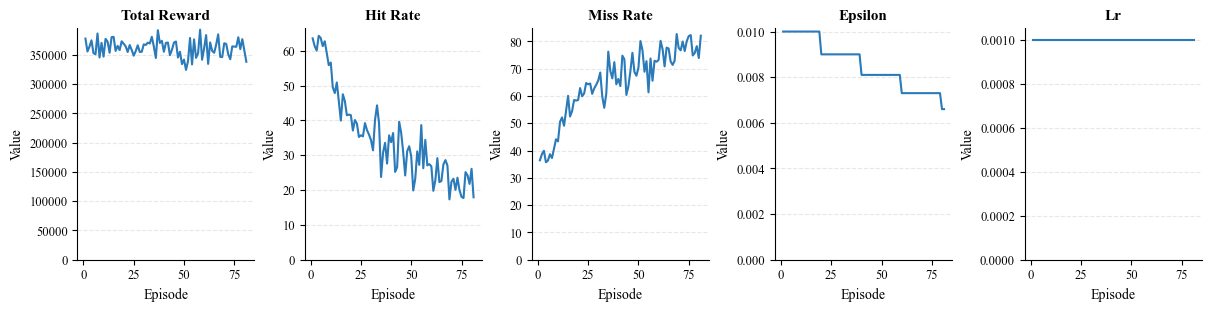

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------------      
# 1. Publication Style Configuration
# ----------------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.8,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True
})

# Professional color for line plots
PRIMARY_COLOR = "#2b7bba"

# ----------------------------------------------------------------
# 2. Data Loading & Smoothing
# ----------------------------------------------------------------
# cfg.filename = "drl_pan_eps0.98_lrdecay0.9999_c50_ar200.0_z0.8.csv"
path = cfg.path_results + "/" + cfg.filename

print(f"Loading data from: {path}")

df = pd.read_csv(path)

total = (df["cache_hits"] + df["cache_misses"]).replace(0, np.nan)
df["hit_rate"] = (df["cache_hits"] / total) * 100
df["miss_rate"] = (df["cache_misses"] / total) * 100

# Metrics to plot
metrics = ["total_reward", "hit_rate", "miss_rate", "epsilon", "lr"]
window_size = 1  # Adjust smoothing window as needed

# ----------------------------------------------------------------
# 3. Plotting logic
# ----------------------------------------------------------------
# Adjusted figsize for a 4-column row (standard for full-width paper figures)
fig, axes = plt.subplots(1, len(metrics), figsize=(12, 3), sharex=True)

for ax, col in zip(axes, metrics):
    # Plot raw data with transparency (alpha)
    ax.plot(df["episode"], df[col], color=PRIMARY_COLOR, alpha=0.3, linewidth=0.8, label='Raw')
    
    # Plot moving average for clearer trend (except for epsilon which is usually linear)
    if col != "epsilon":
        smoothed = df[col].rolling(window=window_size).mean()
        ax.plot(df["episode"], smoothed, color=PRIMARY_COLOR, linewidth=1.5, label='Trend')
    else:
        # Just a solid line for Epsilon
        ax.plot(df["episode"], df[col], color=PRIMARY_COLOR, linewidth=1.5)

    # Stylistic cleanup
    ax.set_title(col.replace("_", " ").title(), fontweight="bold")
    ax.set_xlabel("Episode")
    
    # Remove redundant Y-labels to save space, or keep for clarity
    ax.set_ylabel("Value") 
    
    series = df[col].dropna()
    if not series.empty:
        ymin = series.min()
        ymax = series.max()
        pad = (ymax - ymin) * 0.05 if ymax != ymin else 1.0
        ax.set_ylim(bottom=0)

    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    # Tufte-style: remove top/right spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

# Optional: Add a single legend to the first plot if needed
# axes[0].legend(frameon=False)

plt.show()
fig.savefig("drl_caching_metrics.png", dpi=300)

['lr decay: 0.9995', 'lr decay: 0.9999', 'lr decay: 0.9997', 'lr decay: 0.9997']


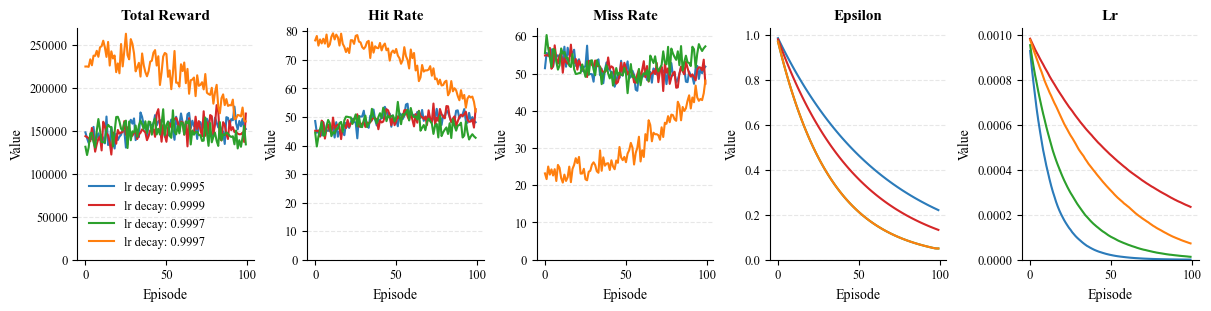

In [ ]:
if __name__ == "__main__":
    cfg = config.Config()

    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif"],
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "legend.fontsize": 9,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.linewidth": 0.8,
        "savefig.dpi": 300,
        "figure.constrained_layout.use": True
    })

    COLORS = ["#2b7bba", "#d62728", "#2ca02c", "#ff7f0e", "#9467bd", "#8c564b"]

    folder = r"c:\Users\es25591\Workspace\CacheVideoPredict360\Results"
    folder= cfg.path_results
    
    files = [
        "drl_pan_eps0.985_lrdecay0.9995_c50_ar200.0_z0.8.csv",
        "drl_pan_eps0.98_lrdecay0.9999_c50_ar200.0_z0.8.csv",
        "drl_pan_eps0.97_lrdecay0.9997_c50_ar200.0_z0.8.csv",
        # "drl_pan_eps0.97_lrdecay0.9997_c100_ar200.0_z0.8.csv"
    ]

    paths = [os.path.join(folder, f) for f in files]
    def _short_label(fname: str) -> str:
        stem = os.path.splitext(fname)[0]
        if "lrdecay" in stem:
            val = stem.split("lrdecay", 1)[1].split("_", 1)[0]
            return f"lr decay: {val}"
        if "fixedlr" in stem:
            val = stem.split("fixedlr", 1)[1].split("_", 1)[0]
            return f"fixed lr: {val}"
        return stem

    labels = [_short_label(f) for f in files]

    print(labels)
    metrics = ["total_reward", "hit_rate", "miss_rate", "epsilon", "lr"]
    window_size = 1

    fig, axes = plt.subplots(1, len(metrics), figsize=(12, 3), sharex=True)

    for color, path, label in zip(COLORS, paths, labels):
        df = pd.read_csv(path).head(100).copy()   # only first 100 values
        total = (df["cache_hits"] + df["cache_misses"]).replace(0, np.nan)
        df["hit_rate"] = (df["cache_hits"] / total) * 100
        df["miss_rate"] = (df["cache_misses"] / total) * 100

        for ax, col in zip(axes, metrics):
            ax.plot(df["episode"], df[col], color=color, alpha=0.25, linewidth=0.8)

            if col != "epsilon":
                smoothed = df[col].rolling(window=window_size).mean()
                ax.plot(df["episode"], smoothed, color=color, linewidth=1.5, label=label)
            else:
                ax.plot(df["episode"], df[col], color=color, linewidth=1.5, label=label)

    for ax, col in zip(axes, metrics):
        ax.set_title(col.replace("_", " ").title(), fontweight="bold")
        ax.set_xlabel("Episode")
        ax.set_ylabel("Value")
        ax.grid(axis="y", linestyle="--", alpha=0.3)
        ax.spines["right"].set_visible(False)
        ax.spines["top"].set_visible(False)
        ax.set_ylim(bottom=0)

    axes[0].legend(frameon=False, loc="best")
    plt.show()

    fig.savefig("interval_04_comparison.png", dpi=300)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------------      
# 1. Publication Style Configuration
# ----------------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.8,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True
})

COLORS = ["#2b7bba", "#d62728"]

# ----------------------------------------------------------------
# 2. Data Preparation with Variance
# ----------------------------------------------------------------
def get_metrics_with_error(path):
    """Returns mean and standard deviation for hit and miss rates."""
    try:
        df = pd.read_csv(path)
        total = (df["cache_hits"] + df["cache_misses"]).replace(0, np.nan)
        
        hit_series = (df["cache_hits"] / total * 100)
        miss_series = (df["cache_misses"] / total * 100)
        
        # Calculate Mean and Standard Deviation
        return (hit_series.mean(), hit_series.std()), (miss_series.mean(), miss_series.std())
    except Exception as e:
        print(f"Error processing {path}: {e}")
        return (0, 0), (0, 0)

drl_files = {
    "5": r"c:\Users\es25591\Workspace\CacheVideoPredict360\Results\drl_pan_opt_c25_ar10.0_z0.5.csv",
    "10": r"c:\Users\es25591\Workspace\CacheVideoPredict360\Results\drl_pan_opt_c50_ar10.0_z0.5.csv",
}

lsr_files = {
    "5": r"c:\Users\es25591\Workspace\CacheVideoPredict360\Results\lru_c25_ar10.0_z0.5.csv",
    "10": r"c:\Users\es25591\Workspace\CacheVideoPredict360\Results\lru_c50_ar10.0_z0.5.csv",
}

caps = list(drl_files.keys())
# Structure: { Metric: { Algo: [means], Algo_err: [stds] } }
stats = {
    "Hit Rate": {"DRL-LSR": [], "DRL-LSR_err": [], "LRU-LSR": [], "LRU-LSR_err": []},
    "Miss Rate": {"DRL-LSR": [], "DRL-LSR_err": [], "LRU-LSR": [], "LRU-LSR_err": []}
}

for c in caps:
    (d_h, d_h_err), (d_m, d_m_err) = get_metrics_with_error(drl_files[c])
    (l_h, l_h_err), (l_m, l_m_err) = get_metrics_with_error(lsr_files[c])
    
    stats["Hit Rate"]["DRL-LSR"].append(d_h)
    stats["Hit Rate"]["DRL-LSR_err"].append(d_h_err)
    stats["Hit Rate"]["LRU-LSR"].append(l_h)
    stats["Hit Rate"]["LRU-LSR_err"].append(l_h_err)
    
    stats["Miss Rate"]["DRL-LSR"].append(d_m)
    stats["Miss Rate"]["DRL-LSR_err"].append(d_m_err)
    stats["Miss Rate"]["LRU-LSR"].append(l_m)
    stats["Miss Rate"]["LRU-LSR_err"].append(l_m_err)

# ----------------------------------------------------------------
# 3. Plotting logic
# ----------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(7, 3.2), sharey=True)
x = np.arange(len(caps))
width = 0.35 

# Error bar styling
error_kw = dict(lw=1, capsize=3, capthick=1, ecolor='#333333')

metrics = ["Hit Rate", "Miss Rate"]
for i, metric in enumerate(metrics):
    ax = axes[i]
    
    ax.bar(x - width/2, stats[metric]["DRL-LSR"], width, 
           yerr=stats[metric]["DRL-LSR_err"], error_kw=error_kw,
           label="DRL-LSR", color=COLORS[0], edgecolor='black', linewidth=0.6, zorder=3)
    
    ax.bar(x + width/2, stats[metric]["LRU-LSR"], width, 
           yerr=stats[metric]["LRU-LSR_err"], error_kw=error_kw,
           label="LRU-LSR", color=COLORS[1], edgecolor='black', linewidth=0.6, zorder=3)

    ax.set_title(f"Average {metric}", fontweight="bold")
    ax.set_xlabel("Cache Size (%)")
    ax.set_xticks(x)
    ax.set_xticklabels(caps)
    ax.set_ylim(0, 110) # Increased to accommodate error bars
    
    ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

axes[0].set_ylabel("Percentage (%)")
axes[1].legend(frameon=False, loc="upper right")

plt.tight_layout()
plt.show()

fig.savefig("drl_vs_lru_cache_performance.pdf")